# 8. Trustworthy features and experimental design

This page covers four questions that come up in most screens:

- which features can I trust?
- how much of what I see is batch effect?
- how many replicates do I need?
- is this hit real, or did the compound kill the cells?

BBBC021 is used for the first three. The fourth uses a synthetic plate, where which
perturbation lost its cells is known in advance.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import mantispy as mt

The recipe from tutorial 6, including the `degenerate_scale` drop it explains.

In [2]:
adata = mt.ds.bbbc021()
mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")
adata = adata[:, ~adata.var["degenerate_scale"].to_numpy()].copy()
mt.pp.feature_select(adata, na_cutoff=0.0)
adata = mt.pp.subset_features(adata)

treated = adata[~adata.obs["Metadata_Control"].to_numpy()].copy()
treated.shape

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/IN9GYQN4/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_4635/3580903452.py:2: UserWarning: 2 of 473 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy(). Feature selection does not catch a feature that varies across a plate but is constant among its control wells.
  mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")


(302, 344)

## Which features can I trust?

A feature with high variance can still be useless. If that variance lies within replicates of
the same treatment rather than between treatments, it is noise. A variance filter cannot tell
the difference because it ignores the replicate structure.

`pp.feature_reproducibility` computes the intraclass correlation (ICC), the share of a
feature's variance that lies between replicate groups.

In [3]:
mt.pp.feature_reproducibility(treated, groupby="Metadata_Perturbation")
icc = treated.var["icc"]
{
    "median": round(float(icc.median()), 3),
    "lower quartile": round(float(icc.quantile(0.25)), 3),
    "upper quartile": round(float(icc.quantile(0.75)), 3),
    "features above 0.2": int((icc > 0.2).sum()),
    "of": int(treated.n_vars),
}

{'median': 0.38,
 'lower quartile': 0.203,
 'upper quartile': 0.537,
 'features above 0.2': 261,
 'of': 344}

Does selecting on ICC help? The answer differs between two retrieval tasks.

Replicate retrieval, whether a treatment's replicates find each other, is what mAP measures.

In [4]:
def replicate_map(profiles):
    """Mean average precision of replicate retrieval."""
    scratch = profiles.copy()
    mt.tl.map(scratch, mode="replicability", null_size=500, seed=0)
    return float(scratch.uns["mantispy"]["map"]["mean_average_precision"].mean())


{
    "all features": round(replicate_map(treated), 3),
    "ICC > 0.2": round(replicate_map(treated[:, (icc > 0.2).to_numpy()].copy()), 3),
    "ICC > 0.4": round(replicate_map(treated[:, (icc > 0.4).to_numpy()].copy()), 3),
}

{'all features': 0.323, 'ICC > 0.2': 0.349, 'ICC > 0.4': 0.375}

Replicate retrieval improves clearly. The same filter improves it on the other two packaged
screens as well (measured separately, not on this page): rohban goes from 0.138 to 0.190 and
pki from 0.252 to 0.261. In relative terms rohban gains the most of the three (+38% against
+8% for BBBC021) and pki the least, so the size of the gain depends on the screen and has to
be measured.

Mechanism retrieval, whether a compound finds a different compound with the same mechanism,
is the task from tutorial 6. Here the same filter does not help.

In [5]:
def not_same_compound(profiles):
    """Not-same-compound mechanism retrieval, as in tutorial 6."""
    signatures = mt.tl.consensus(profiles.copy(), method="median", min_replicates=1)
    signatures = signatures[signatures.obs["Metadata_MOA"].notna().to_numpy()].copy()
    mt.tl.nn_moa_classify(signatures, scheme="nsc")
    return float(signatures.uns["mantispy"]["moa"]["accuracy"])


{
    "all features": round(not_same_compound(treated), 3),
    "ICC > 0.2": round(not_same_compound(treated[:, (icc > 0.2).to_numpy()].copy()), 3),
    "ICC > 0.4": round(not_same_compound(treated[:, (icc > 0.4).to_numpy()].copy()), 3),
}

{'all features': 0.777, 'ICC > 0.2': 0.767, 'ICC > 0.4': 0.757}

Reproducible and generalizable are different properties. ICC favors features whose
replicates agree, which is what replicate retrieval rewards. Transferring from one molecule to
another with the same mechanism needs something else, and filtering on reproducibility
slightly hurts it here.

Use ICC when the question is reproducibility. For other tasks, measure its effect first, and
choose the cutoff from the ICC distribution instead of using a default.

## How much of this is batch effect?

`pp.feature_batch_sensitivity` tests each feature for dependence on batch with a
Kruskal-Wallis test and corrects for multiple testing across features. Run it after any
correction you applied, to see what batch dependence remains.

In [6]:
mt.pp.feature_batch_sensitivity(treated, batch_key="Metadata_Plate")
{
    "plates": int(treated.obs["Metadata_Plate"].nunique()),
    "features still plate-dependent at q < 0.05": int(treated.var["batch_sensitive"].sum()),
    "of": int(treated.n_vars),
}

{'plates': 49, 'features still plate-dependent at q < 0.05': 338, 'of': 344}

Nearly every feature depends on batch after per-plate normalization. Centering each plate on
its own controls removes the plate's offset, but not differences in how features respond
within the plate.

Treat this as a warning against interpreting small effects across plates. Compare a corrected
run with an uncorrected one to see whether the count drops, and evaluate corrections with
`mt.metrics.evaluate_correction`.

## How many replicates do I need?

`tl.replicate_saturation` subsamples replicates and reports how much the signature still
changes at each depth. There are two metrics, and the number of replicates in the screen
decides which one applies:

- `"signature_stability"` correlates two disjoint subsets. It is unbiased and needs
  `2 * depth` replicates.
- `"convergence"` correlates a subset with the group's full signature. It is defined up to
  one less than the group size and is optimistic by construction.

BBBC021 has three replicates per treatment, so the unbiased measure gives a single point.

In [7]:
mt.tl.replicate_saturation(treated, metric="convergence", n_draws=10)
treated.uns["mantispy"]["replicate_saturation"].round(3)

,n_replicates,mean,std,n_draws
0,1,0.793,0.009,10
1,2,0.873,0.004,10


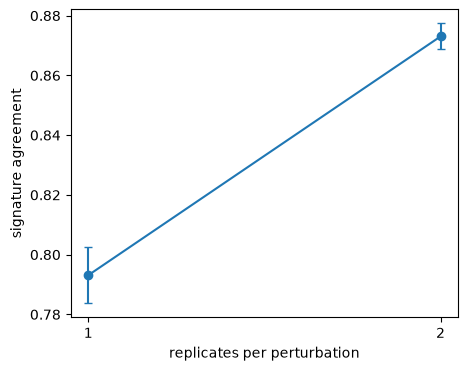

In [8]:
ax = mt.pl.replicate_saturation(treated)
plt.show()

From one replicate to two, signature agreement rises from 0.79 to 0.87 and is still rising at
the largest depth the data supports. For an experiment that has to distinguish mechanisms,
three replicates is on the low side, which is useful when planning the next screen.

## Is it a hit, or did the cells die?

A compound that kills four fifths of the cells leaves a well median computed from a fifth as
many cells, and that median moves away from the controls for reasons unrelated to the biology
being screened. It looks like a strong hit.

The cell count is also a baseline to beat. {cite:t}`Seal_2025` found that across three
bioactivity benchmarks a model given only the cell count often matched one given the whole
Cell Painting profile, and {cite:t}`Ewald_2026` found that profiles predicted LDH release no
better than cell count, plate and well position.

So that the answer is known in advance, this section uses a synthetic plate where one
perturbation is purely cytotoxic: 80% of its cells are removed and its injected morphology
effect is subtracted again. Only the cell loss remains.

In [9]:
plate = mt.ds.synthetic_plate(n_wells=192, n_cells=50, n_features=25, n_perturbations=3, effect_size=3.0, seed=0)
rng = np.random.default_rng(0)

toxic = (plate.obs["Metadata_Perturbation"] == "pert02").to_numpy()
plate = plate[~toxic | (rng.random(plate.n_obs) < 0.2)].copy()

rows = (plate.obs["Metadata_Perturbation"] == "pert02").to_numpy()
values = plate.X.copy()
for name in plate.uns["mantispy"]["truth"]["affected_features"]["pert02"]:
    column = list(plate.var_names).index(name)
    values[rows, column] -= values[rows, column].mean() - values[~rows, column].mean()
plate.X = values

mt.pp.normalize(plate, by="Metadata_Plate", reference="negcon")
wells = mt.tl.aggregate(plate, min_cells=0)
mt.tl.hit_calling(wells, n_permutations=500)
wells.uns["mantispy"]["hits"][["group", "distance", "qvalue", "is_hit"]].round(3)

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_4635/2037011891.py:16: UserWarning: the covariance is estimated from 24 of 48 reference rows (half the controls) for 25 features, so it is singular and the Mahalanobis distances are dominated by the regularization. Reduce the features with mt.pp.feature_select, or score a PCA representation with use_rep='X_pca'.
  mt.tl.hit_calling(wells, n_permutations=500)


,group,distance,qvalue,is_hit
0,DMSO,270.174,0.419,False
1,pert00,2831.307,0.003,True
2,pert01,2414.603,0.003,True
3,pert02,661.269,0.003,True


pert02 has no morphology effect left and is still called a hit, at 661 against 270 for the
controls. Hit calling cannot tell the difference, because nothing in the profile says why it
moved. (The covariance warning is the one explained in [tutorial
5](05_hits_and_effects.ipynb): 24 control rows for 25 features. It affects the scale of these
distances, not their order.)

In [10]:
mt.tl.cytotoxicity(wells)
wells.uns["mantispy"]["cytotoxicity"].round(3)

,group,n_obs,viability,distance,suspect
0,DMSO,48,1.0,270.174,False
1,pert00,48,1.0,2831.307,False
2,pert01,48,1.0,2414.603,False
3,pert02,48,0.2,661.269,True


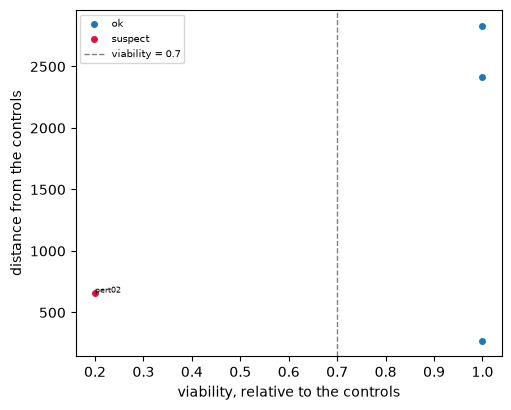

In [11]:
ax = mt.pl.cytotoxicity(wells)
plt.show()

pert02 has a viability of 0.20 and is the only group flagged. The two perturbations with real
effects and no cell loss are not flagged.

Both conditions have to hold. Cell loss alone is a phenotype (a compound that arrests growth
is a real finding), and a large distance alone is a hit. Only the combination is suspect.

How much this matters depends on the screen. Measured separately on the other two packaged
screens, the rank correlation between phenotype distance and cell loss is +0.79 over the pki
dose series and +0.00 over rohban's ORF overexpression. `tl.cytotoxicity` is a diagnostic and
does not correct anything.

## Genetic screens: does the screen recover known biology?

When the perturbation is a gene rather than a compound, gene-set resources apply.
`tl.gene_sets` fetches one through decoupler, and `tl.pathway_coherence` tests whether the
genes of a set produce similar morphologies, against a null of random sets of the same
size.

This needs a `Metadata_Gene` column, so it does not apply to BBBC021. `rohban` has
`Metadata_GeneID` and `Metadata_Perturbation`. Either can be copied into `Metadata_Gene`; the
snippet below uses the perturbation because `consensus` groups on it:

```python
genes = mt.tl.consensus(rohban, method="median", min_replicates=2)
genes.obs["Metadata_Gene"] = genes.obs["Metadata_Perturbation"].astype(str).to_numpy()

net = mt.tl.gene_sets("hallmark")
mt.tl.pathway_coherence(genes, net, min_genes=4)
mt.pl.pathway_coherence(genes)
```

Run this way (measured separately, not on this page), hallmark covers 133 of the screen's 190
genes, and 29 sets have enough members to score. No set passes FDR; the most coherent is
`COMPLEMENT` at q = 0.51. At this power the screen does not recover hallmark program
structure. Hallmark sets are transcriptional programs, and the test asks whether
overexpressing genes from the same program produces similar morphology, which need not be the
case.

The table is sorted by coherence, not by p-value. With a permutation null every coherent set
ties at the smallest possible p-value, so the p-value shows whether a set is coherent and the
statistic ranks the sets.

## Summary

- Reproducibility and generalizability are different properties, and a filter that
  improves one can hurt the other. Measure the task you care about.
- Per-plate normalization does not remove all plate structure. Check what remains.
- A saturation curve that is still rising says the next experiment needs more replicates.
- Cell loss and phenotype are confounded by construction. Flag the combination instead of
  correcting it away.

Next: [9. Scaling up, and correcting across laboratories](09_scaling_and_sites.ipynb), on
data that does not fit in memory and data from two laboratories.